# Análisis de Series de Tiempo: Modelos de Suavizamiento Exponencial

Este notebook tiene como objetivo explorar y comparar diferentes técnicas de **Suavizamiento Exponencial** para la predicción de series de tiempo. Utilizaremos el dataset de producción/pasajeros para evaluar cómo responden los modelos ante la presencia de tendencia y estacionalidad.

**Técnicas a evaluar:**
1. **Simple Exponential Smoothing (SES):** Para series sin tendencia ni estacionalidad.
2. **Holt’s Linear Trend:** Para series con tendencia pero sin estacionalidad.
3. **Holt-Winters (Triple):** Para series con tendencia y ciclos estacionales.

In [23]:
from tokenize import PlainToken
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
import matplotlib.pyplot as plt

### 1 Read Data

In [24]:
airpax_data = pd.read_csv("AirPassengers.csv")
airpax_data['Month'] = pd.to_datetime(airpax_data['Month'],infer_datetime_format=True) #convert from string to datetime
airpax_data = airpax_data.set_index(['Month'])
airpax_data.head()

C:\Users\sarud\AppData\Local\Temp\ipykernel_23292\817330162.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  airpax_data['Month'] = pd.to_datetime(airpax_data['Month'],infer_datetime_format=True) #convert from string to datetime


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 2 Plot data

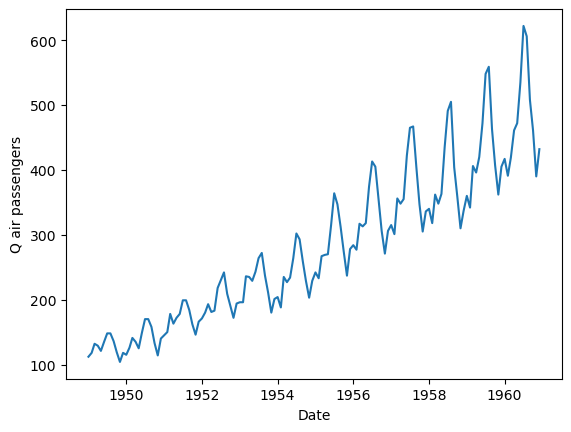

In [25]:
## plot graph
plt.xlabel('Date')
plt.ylabel('Q air passengers')
plt.plot(airpax_data)

### Análisis Exploratorio de la Serie
Al observar el gráfico inicial, podemos identificar las siguientes características:
* **Tendencia:** ¿Existe un crecimiento o decrecimiento sostenido en el tiempo?
* **Estacionalidad:** ¿Se repiten patrones en periodos fijos (ej. cada 12 meses)?
* **Variabilidad:** ¿La amplitud de las variaciones es constante (Aditiva) o crece proporcionalmente al nivel de la serie (Multiplicativa)?

*Nota: Es fundamental asegurar que el índice tenga una frecuencia definida (`df.index.freq`) para que los modelos de `statsmodels` funcionen correctamente.*

### 3 Descomponer la serie de tiempo 
#### 3.1 Tipo aditivo

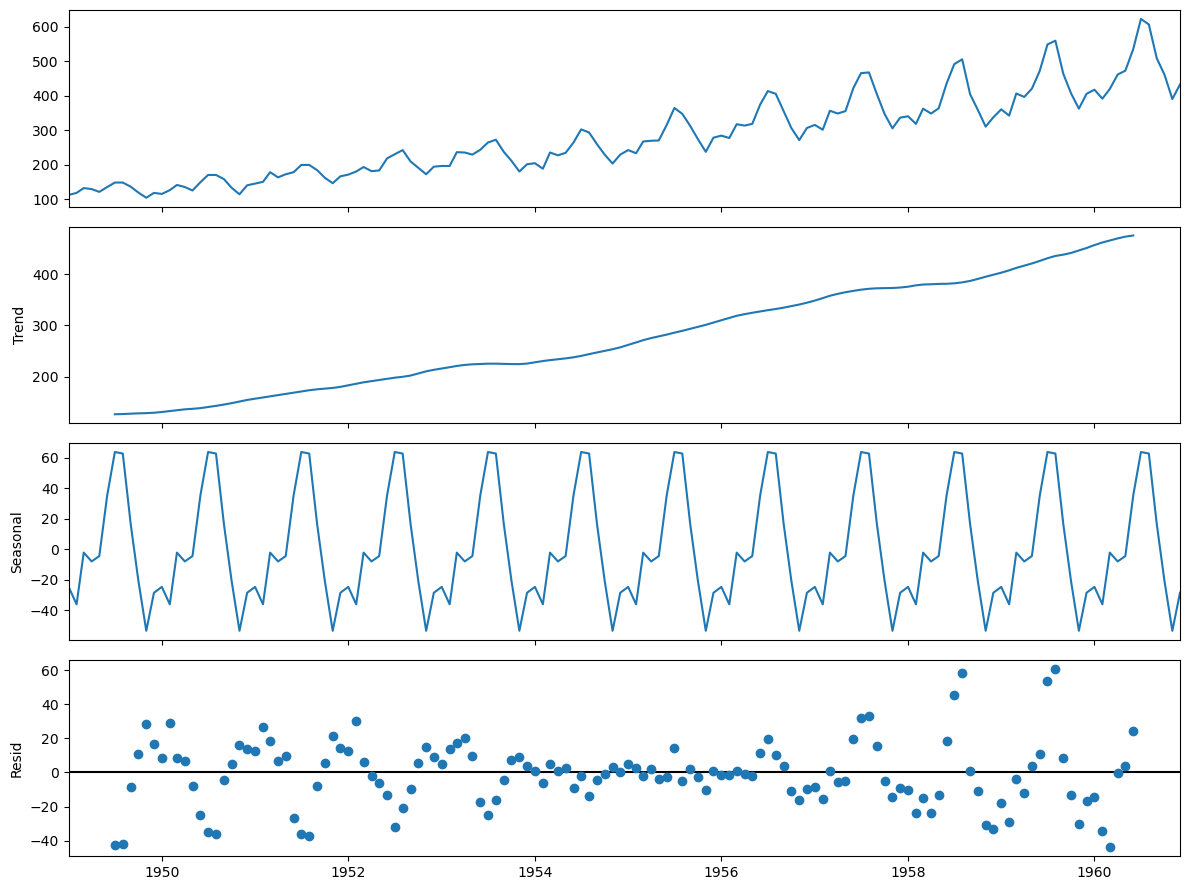

In [26]:
decomp_viz = seasonal_decompose(airpax_data,model='additive', period=12)
fig = decomp_viz.plot()
fig.set_size_inches((12, 9))
# Tight layout to realign things
fig.tight_layout()
plt.show()

#### 3.2 Tipo multiplicativo

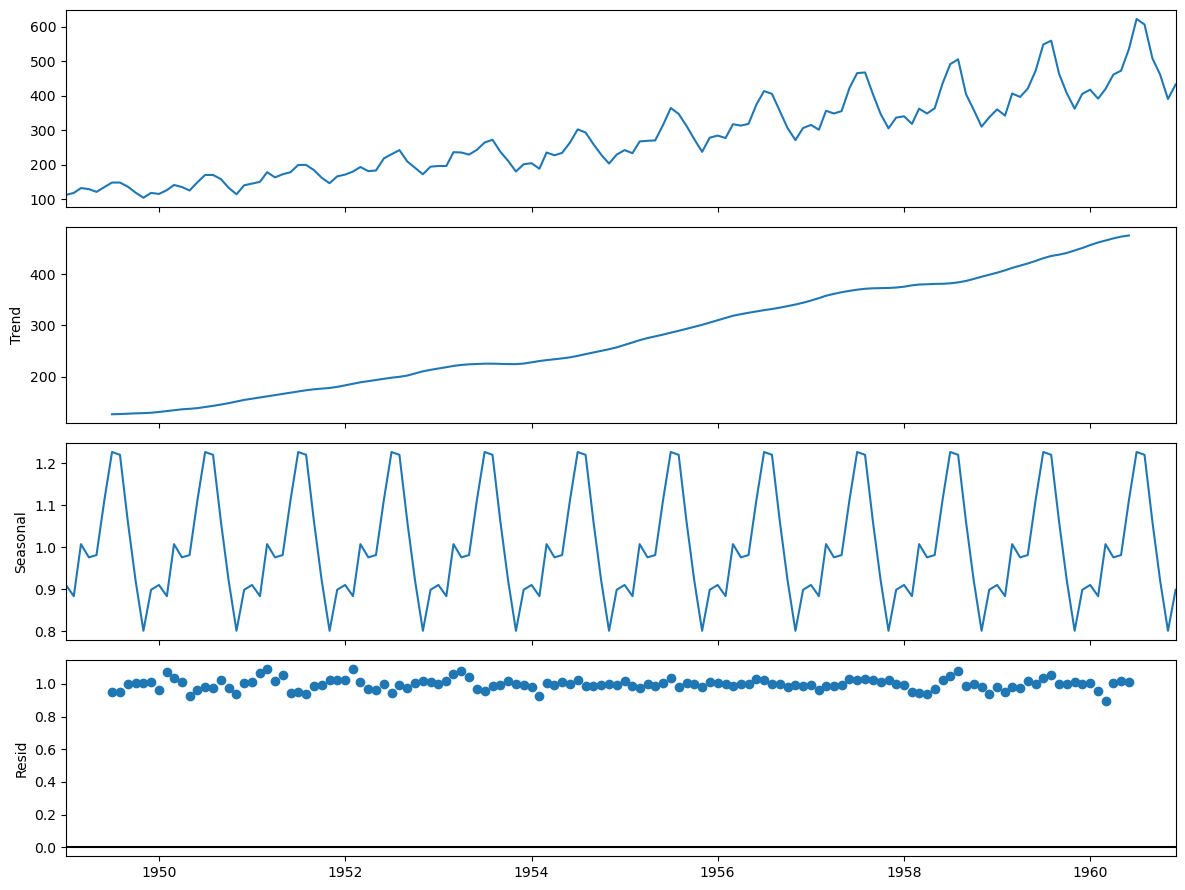

In [27]:
decomp_viz = seasonal_decompose(airpax_data,model='multiplicative', period=12)
fig = decomp_viz.plot()
fig.set_size_inches((12, 9))
# Tight layout to realign things
fig.tight_layout()
plt.show()

Al observar los residuos, se observa una tendencia más multiplicativa que aditiva.

## Aplicación de Modelos Base

Comenzamos con los modelos que no consideran estacionalidad. El modelo **Simple** asigna pesos decrecientes a las observaciones pasadas, mientras que el modelo de **Holt** añade un parámetro para capturar la pendiente (tendencia) de los datos.

### 1. Modelo simple

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: title={'center': 'Single Exponential Smoothing'}, xlabel='Month'>

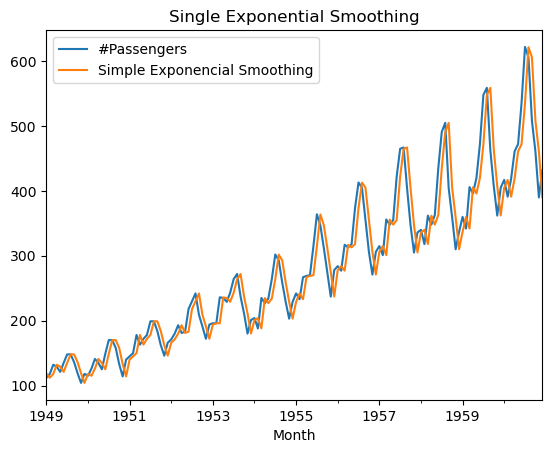

In [28]:
HWES1 = SimpleExpSmoothing(airpax_data, initialization_method="estimated").fit()
HWES1_fitted = HWES1.fittedvalues
HWES1_fitted.name = 'Simple Exponencial Smoothing'
pd.concat([airpax_data, HWES1_fitted], axis=1).plot(title='Single Exponential Smoothing')

In [29]:
results = pd.DataFrame(
    index=["SSE", "AIC", "BIC"])
results["Simple Exponencial"] = [HWES1.sse] + [HWES1.aic] + [HWES1.bic] 

#### 2. Modelo Holt

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


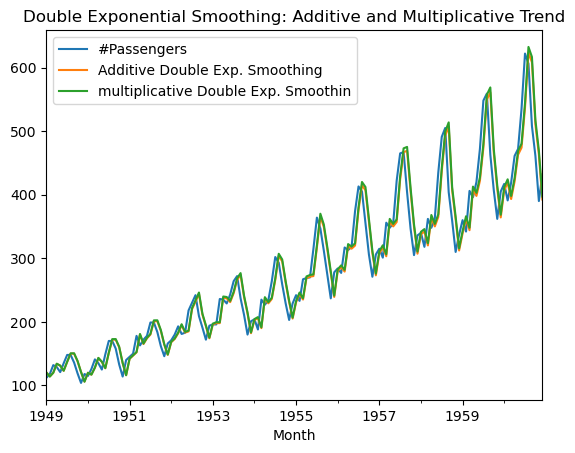

In [30]:
HWES2_ADD = ExponentialSmoothing(airpax_data,trend='add').fit()#.fittedvalues
HWES2_MUL = ExponentialSmoothing(airpax_data,trend='mul').fit()#.fittedvalues
HWES2_ADD_fitted = HWES2_ADD.fittedvalues
HWES2_MUL_fitted = HWES2_MUL.fittedvalues
HWES2_ADD_fitted.name = 'Additive Double Exp. Smoothing'
HWES2_MUL_fitted.name = 'multiplicative Double Exp. Smoothin'
pd.concat([airpax_data, HWES2_ADD_fitted, HWES2_MUL_fitted], axis=1).plot(title='Double Exponential Smoothing: Additive and Multiplicative Trend');

In [31]:
results["Double Exp. - Additive"] = [HWES2_ADD.sse] + [HWES2_ADD.aic] + [HWES2_ADD.bic] 
results["Double Exp. - Multiplicative"] = [HWES2_MUL.sse] + [HWES2_MUL.aic] + [HWES2_MUL.bic] 

## Modelo Holt-Winters (Suavizamiento Exponencial Triple)

Este es el modelo más robusto para esta serie, ya que incorpora una tercera componente: la **Estacionalidad**. 
* Si la amplitud del ciclo estacional es constante, usamos el método **Aditivo**.
* Si la amplitud crece junto con la tendencia, el método **Multiplicativo** suele ofrecer mejores resultados.

In [32]:
fit1 = ExponentialSmoothing(
    airpax_data,
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit2 = ExponentialSmoothing(
    airpax_data,
    seasonal_periods=12,
    trend="add",
    seasonal="mul",
    initialization_method="estimated",
).fit()

fit3 = ExponentialSmoothing(
    airpax_data,
    seasonal_periods=12,
    trend="mul",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit4 = ExponentialSmoothing(
    airpax_data,
    seasonal_periods=12,
    trend="mul",
    seasonal="mul",
    initialization_method="estimated",
).fit()

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferre

In [33]:
results["Holt Trend-Add Seas-Add"] = [fit1.sse] + [fit1.aic] + [fit1.bic]
results["Holt Trend-Add Seas-Mul"] = [fit2.sse] + [fit2.aic] + [fit2.bic]
results["Holt Trend-Mul Seas-Add"] = [fit3.sse] + [fit3.aic] + [fit3.bic]
results["Holt Trend-Mul Seas-Mul"] = [fit4.sse] + [fit4.aic] + [fit4.bic]

Revisar que modelo se comporta mejor

In [34]:
results

,Simple Exponencial,Double Exp. - Additive,Double Exp. - Multiplicative,Holt Trend-Add Seas-Add,Holt Trend-Add Seas-Mul,Holt Trend-Mul Seas-Add,Holt Trend-Mul Seas-Mul
SSE,163044.779418,162374.167750,166903.890794,21564.347029,15952.880750,21093.117831,15805.297331
AIC,1016.603228,1020.009727,1023.971858,753.293599,709.891722,750.111987,708.553348
BIC,1022.542855,1031.888981,1035.851111,800.810612,757.408735,797.629000,756.070361


El modelo multiplicativo en tendencia y estacionariedad es aquel con mejor performance (menor AIC, BIC y SSE)

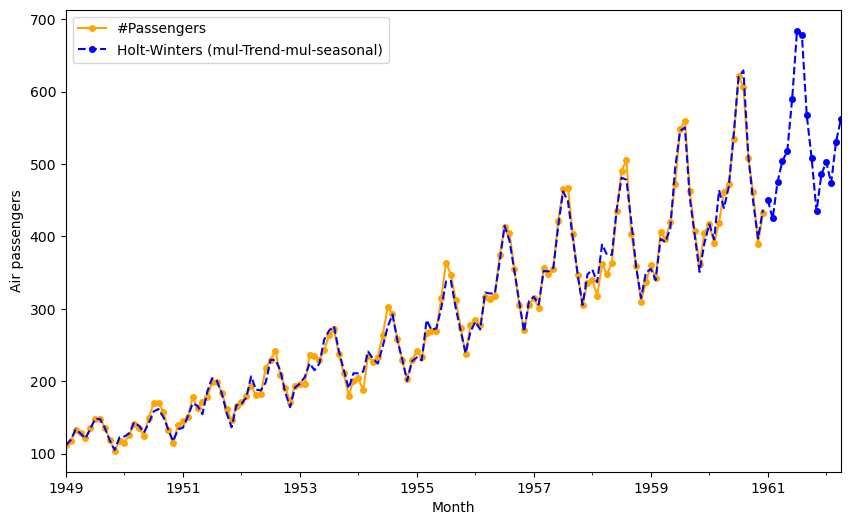

In [35]:
ax = airpax_data.plot(
    figsize=(10, 6),
    marker="o",
    color="orange",
    markersize=4
)

ax.set_ylabel("Air passengers")
ax.set_xlabel("Year")
fit4.fittedvalues.plot(ax=ax, style="--", color="blue")
fit4.forecast(16).rename("Holt-Winters (mul-Trend-mul-seasonal)").plot(
    ax=ax, style="--", marker="o", color="blue", markersize=4, legend=True
)

plt.show()

## Conclusiones y Selección del Modelo

Tras comparar las predicciones con los datos reales:
1. El modelo **SES** falla al no capturar la dirección de la serie.
2. El modelo de **Holt** captura la dirección pero ignora los ciclos anuales.
3. El modelo **Holt-Winters** es el que mejor se ajusta a la realidad visual de los datos.

**Próximos pasos:** Evaluar métricas de error como el **RMSE** (Root Mean Squared Error) o el **MAPE** para cuantificar la precisión de cada modelo de manera objetiva.